# FoodHub Order Analysis
### Exploratory Data Analysis of a New York Food Delivery Platform

---

**Author:** Kanak Sharma  
**Dataset:** FoodHub Order Data (1,898 orders)  
**Tools:** Python · Pandas · Matplotlib · Seaborn

---

## Context

The number of restaurants in New York is increasing day by day. Students and busy professionals rely on food delivery services for their hectic lifestyles. **FoodHub** is a food aggregator that provides access to multiple restaurants through a single smartphone app.

The app allows restaurants to receive direct online orders from customers, assigns a delivery person to pick up the order, and tracks the entire delivery journey. Customers can rate the order after delivery. FoodHub earns revenue by collecting a fixed margin of each order from the restaurants.

## Objective

The goal of this analysis is to:

- Understand demand patterns across restaurants, cuisines, and days of the week
- Analyze food preparation and delivery time distributions
- Identify factors that influence customer ratings
- Calculate key revenue metrics
- Provide actionable business recommendations to help FoodHub grow

## Data Dictionary

| Column | Description |
|---|---|
| `order_id` | Unique identifier for each order |
| `customer_id` | Unique identifier for each customer |
| `restaurant_name` | Name of the restaurant |
| `cuisine_type` | Type of cuisine ordered |
| `cost_of_the_order` | Cost of the order (USD) |
| `day_of_the_week` | Whether the order was placed on a Weekday (Mon–Fri) or Weekend (Sat–Sun) |
| `rating` | Customer rating out of 5, or 'Not given' |
| `food_preparation_time` | Minutes taken by the restaurant to prepare the food |
| `delivery_time` | Minutes taken by the delivery person to deliver the food |

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Overview](#2-data-overview)
   - [Missing Values](#missing-values)
   - [Statistical Summary](#statistical-summary)
   - [Rating Distribution Overview](#rating-distribution-overview)
3. [Demand Analysis](#3-demand-analysis)
   - [Cuisine Type Distribution](#cuisine-type-distribution)
   - [Weekday vs Weekend Orders](#weekday-vs-weekend-orders)
   - [Top Restaurants by Order Volume](#top-restaurants-by-order-volume)
   - [Most Frequent Customers](#most-frequent-customers)
4. [Time & Delivery Analysis](#4-time--delivery-analysis)
   - [Distribution of Preparation and Delivery Times](#distribution-of-preparation-and-delivery-times)
   - [Orders Exceeding 60 Minutes Total Delivery Time](#orders-exceeding-60-minutes-total-delivery-time)
   - [Delivery Time: Weekday vs Weekend](#delivery-time-weekday-vs-weekend)
   - [Food Preparation Time by Cuisine](#food-preparation-time-by-cuisine)
5. [Revenue Analysis](#5-revenue-analysis)
   - [Order Cost Distribution](#order-cost-distribution)
   - [Net Revenue Calculation](#net-revenue-calculation)
6. [Rating Analysis](#6-rating-analysis)
   - [Correlation Between Numerical Variables](#correlation-between-numerical-variables)
   - [Do Cost, Preparation Time, or Delivery Time Affect Ratings?](#do-cost-preparation-time-or-delivery-time-affect-ratings)
   - [Restaurants Qualifying for Promotional Offers](#restaurants-qualifying-for-promotional-offers)
7. [Conclusions & Recommendations](#7-conclusions--recommendations)

---
## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14, 'axes.labelsize': 12})

In [5]:
# Load the dataset — place foodhub_order.csv in a 'data/' folder next to this notebook
food = pd.read_csv('data/foodhub_order.csv')
print(f"Dataset loaded: {food.shape[0]:,} rows × {food.shape[1]} columns")
food.head()

Mounted at /content/drive
Dataset loaded: 1,898 rows × 9 columns


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


---
## 2. Data Overview

In [8]:
# Dataset shape and column data types
print(f"Shape: {food.shape[0]:,} rows × {food.shape[1]} columns\n")
food.info()

Shape: 1,898 rows × 9 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


**Observations:**
- The dataset has **1,898 rows** and **9 columns**.
- `restaurant_name`, `cuisine_type`, `day_of_the_week`, and `rating` are object (string) columns.
- `cost_of_the_order` is float; all timing columns are integers.
- All data types appear correct for their respective columns.

### Missing Values

In [13]:
food.isnull().sum().to_frame('missing_count')

,missing_count
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


**Observations:**
- There are **no missing values** in any column. The dataset is complete and requires no imputation.

### Statistical Summary

In [14]:
food.describe().round(2)

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1898.00,1898.00,1898.00,1898.00,1898.00
mean,1477495.50,171168.48,16.50,27.37,24.16
std,548.05,113698.14,7.48,4.63,4.97
min,1476547.00,1311.00,4.47,20.00,15.00
25%,1477021.25,77787.75,12.08,23.00,20.00
50%,1477495.50,128600.00,14.14,27.00,25.00
75%,1477969.75,270525.00,22.30,31.00,28.00
max,1478444.00,405334.00,35.41,35.00,33.00


**Key takeaways from the summary:**
- **Food preparation time** ranges from 20 to 35 minutes, with a mean of ~27.4 minutes.
- **Delivery time** ranges from 15 to 33 minutes, with a mean of ~24.2 minutes.
- **Order cost** ranges from $4.47 to $35.41, with a mean of ~$16.50.
- `order_id` and `customer_id` are identifiers and will not be used in analysis.

### Rating Distribution Overview

In [17]:
rating_counts = food['rating'].value_counts() # count of each unique rating value (3, 4, 5, Not given)
unrated = food[food['rating'] == 'Not given'].shape[0] # number of orders where customer left no rating
print(f"Total orders     : {len(food):,}")
print(f"Unrated orders   : {unrated:,} ({unrated/len(food)*100:.1f}%)")
print(f"Rated orders     : {len(food)-unrated:,} ({(len(food)-unrated)/len(food)*100:.1f}%)")
print()
print("Rating breakdown:")
print(rating_counts.to_string())

Total orders     : 1,898
Unrated orders   : 736 (38.8%)
Rated orders     : 1,162 (61.2%)

Rating breakdown:
rating
Not given    736
5            588
4            386
3            188


**Observations:**
- **736 orders (38.8%)** were not rated — a significant gap in customer feedback.
- Among rated orders, customers tend to give high ratings: 5 is the most common (588 orders), followed by 4 (390), then 3 (190).
- Very few customers are explicitly dissatisfied (rating of 3 is the lowest count).

---
## 3. Demand Analysis

This section explores which cuisines, restaurants, and time periods drive the most orders.

### Cuisine Type Distribution

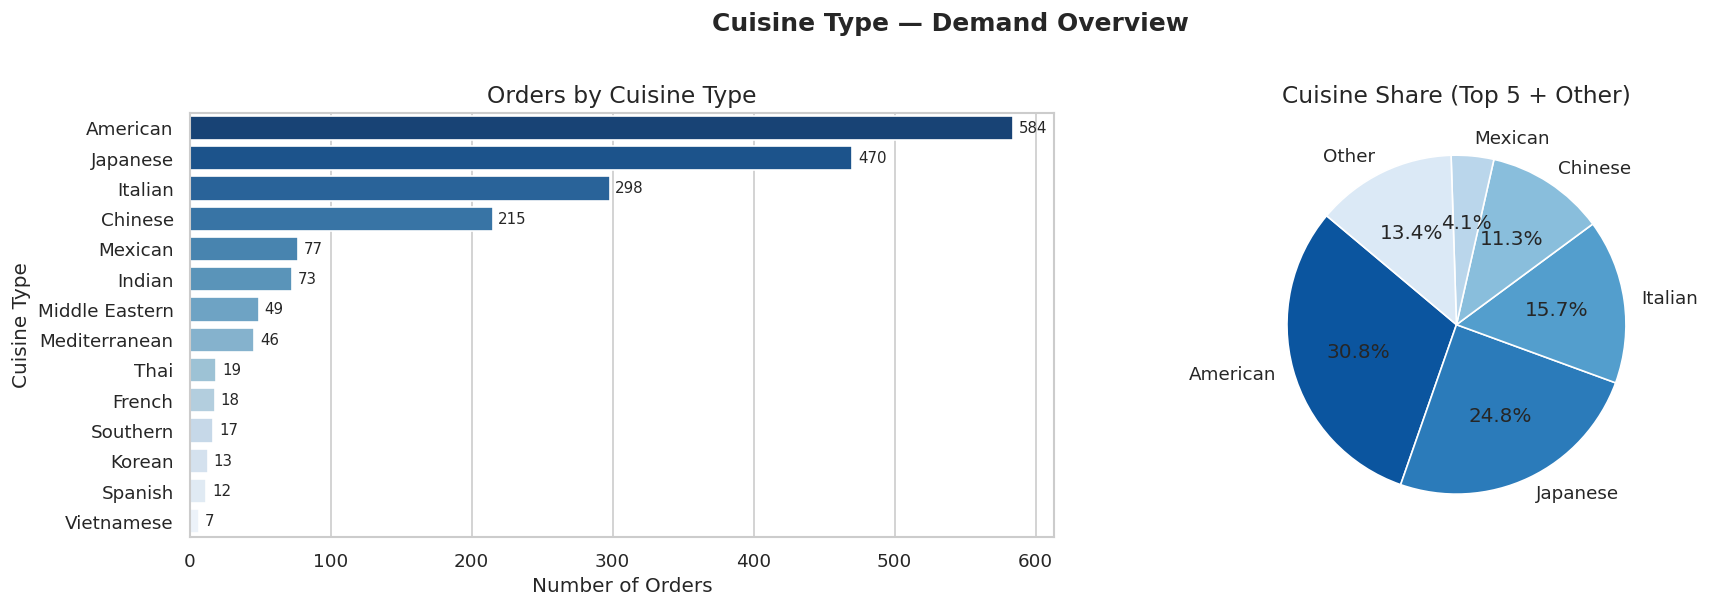

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Order counts by cuisine
cuisine_counts = food['cuisine_type'].value_counts()
sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Orders by Cuisine Type')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Cuisine Type')
for bar, val in zip(axes[0].patches, cuisine_counts.values):
    axes[0].text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)

# Percentage share pie (top 5 + other)
top5_cuisine = cuisine_counts.head(5)
other = cuisine_counts[5:].sum()
pie_data = pd.concat([top5_cuisine, pd.Series({'Other': other})])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Blues_r', len(pie_data)))
axes[1].set_title('Cuisine Share (Top 5 + Other)')

plt.suptitle('Cuisine Type — Demand Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- **American** cuisine dominates with ~585 orders, followed by **Japanese** (~470) and **Italian** (~300).
- The bottom cuisines — Vietnamese, Spanish, and Korean — each have fewer than 15 orders.
- The top 3 cuisines account for over **72%** of all orders, indicating highly concentrated demand.

### Weekday vs Weekend Orders

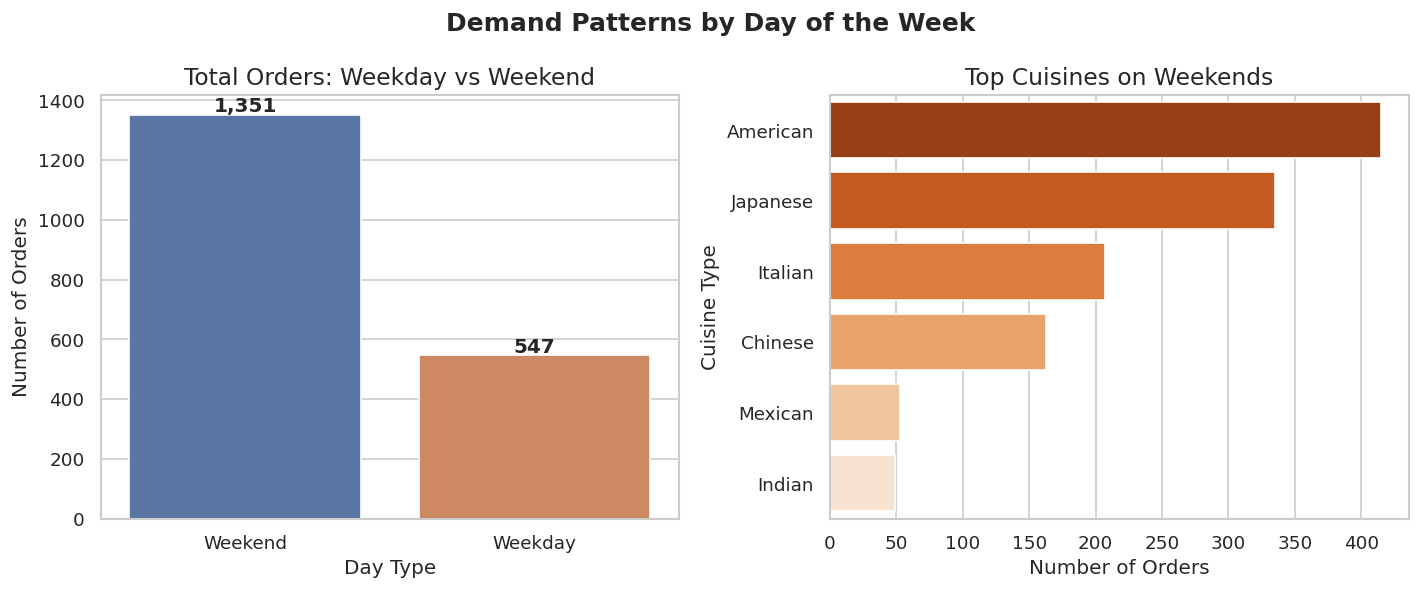

Weekend-to-weekday order ratio: 2.47x


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

day_counts = food['day_of_the_week'].value_counts()
colors = ['#4C72B0', '#DD8452']

sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[0], palette=colors)
axes[0].set_title('Total Orders: Weekday vs Weekend')
axes[0].set_xlabel('Day Type')
axes[0].set_ylabel('Number of Orders')
for bar, val in zip(axes[0].patches, day_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', fontweight='bold')

# Most popular cuisine on weekends
weekend_cuisine = food[food['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().head(6)
sns.barplot(x=weekend_cuisine.values, y=weekend_cuisine.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top Cuisines on Weekends')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Cuisine Type')

plt.suptitle('Demand Patterns by Day of the Week', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

ratio = day_counts['Weekend'] / day_counts['Weekday']
print(f"Weekend-to-weekday order ratio: {ratio:.2f}x")

**Observations:**
- **Weekend orders (1,351)** are nearly **2.5× higher** than weekday orders (547).
- The platform is heavily weekend-driven — this has major implications for delivery staffing.
- **American cuisine** is the most popular on weekends too, with 415 orders.

### Top Restaurants by Order Volume

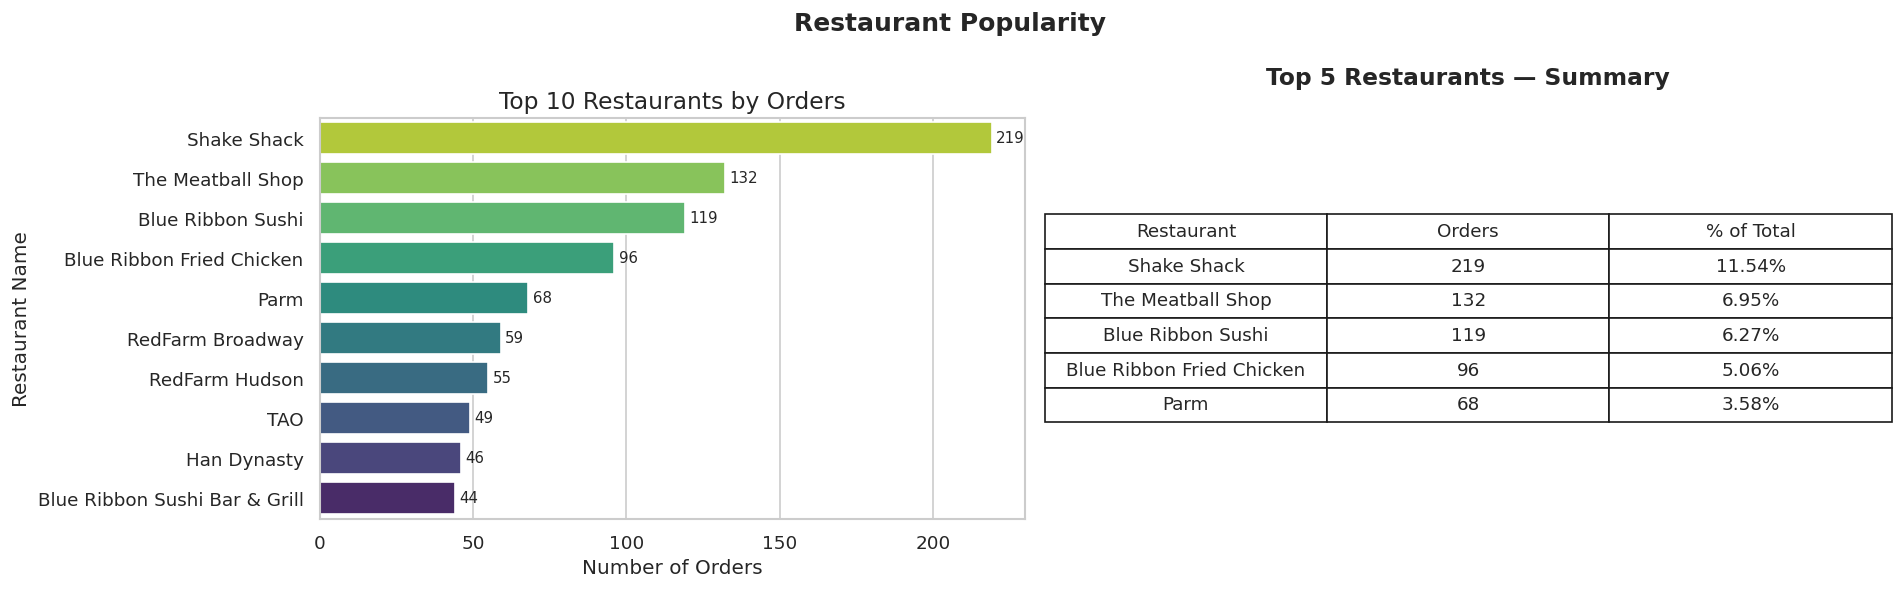

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10
top10 = food['restaurant_name'].value_counts().head(10)
sns.barplot(x=top10.values, y=top10.index, ax=axes[0], palette='viridis_r')
axes[0].set_title('Top 10 Restaurants by Orders')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Restaurant Name')
for bar, val in zip(axes[0].patches, top10.values):
    axes[0].text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

# Top 5 table
top5 = food['restaurant_name'].value_counts().head(5).reset_index()
top5.columns = ['Restaurant', 'Orders']
top5['% of Total'] = (top5['Orders'] / len(food) * 100).round(2).astype(str) + '%'

axes[1].axis('off')
table = axes[1].table(
    cellText=top5.values,
    colLabels=top5.columns,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
axes[1].set_title('Top 5 Restaurants — Summary', fontweight='bold', pad=20)

plt.suptitle('Restaurant Popularity', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- **Shake Shack** leads by a large margin with 219 orders (11.54%) — nearly double the second-place restaurant.
- **The Meatball Shop** (132), **Blue Ribbon Sushi** (119), and **Blue Ribbon Fried Chicken** (96) round out the top four.
- The top 5 restaurants together account for ~33% of all orders.

### Most Frequent Customers

In [23]:
top3_customers = food['customer_id'].value_counts().head(3).reset_index()
top3_customers.columns = ['Customer ID', 'Order Count']
top3_customers['Eligible for Voucher'] = '✓ Yes (20% discount)'
print("Top 3 Most Frequent Customers:")
print(top3_customers.to_string(index=False))

Top 3 Most Frequent Customers:
 Customer ID  Order Count Eligible for Voucher
       52832           13 ✓ Yes (20% discount)
       47440           10 ✓ Yes (20% discount)
       83287            9 ✓ Yes (20% discount)


**Observations:**
- Customers **52832, 47440, and 83287** are the top 3 most frequent — each will receive 20% discount vouchers.

---
## 4. Time & Delivery Analysis

This section examines food preparation and delivery time distributions, and how they vary by day and cuisine.

### Distribution of Preparation and Delivery Times

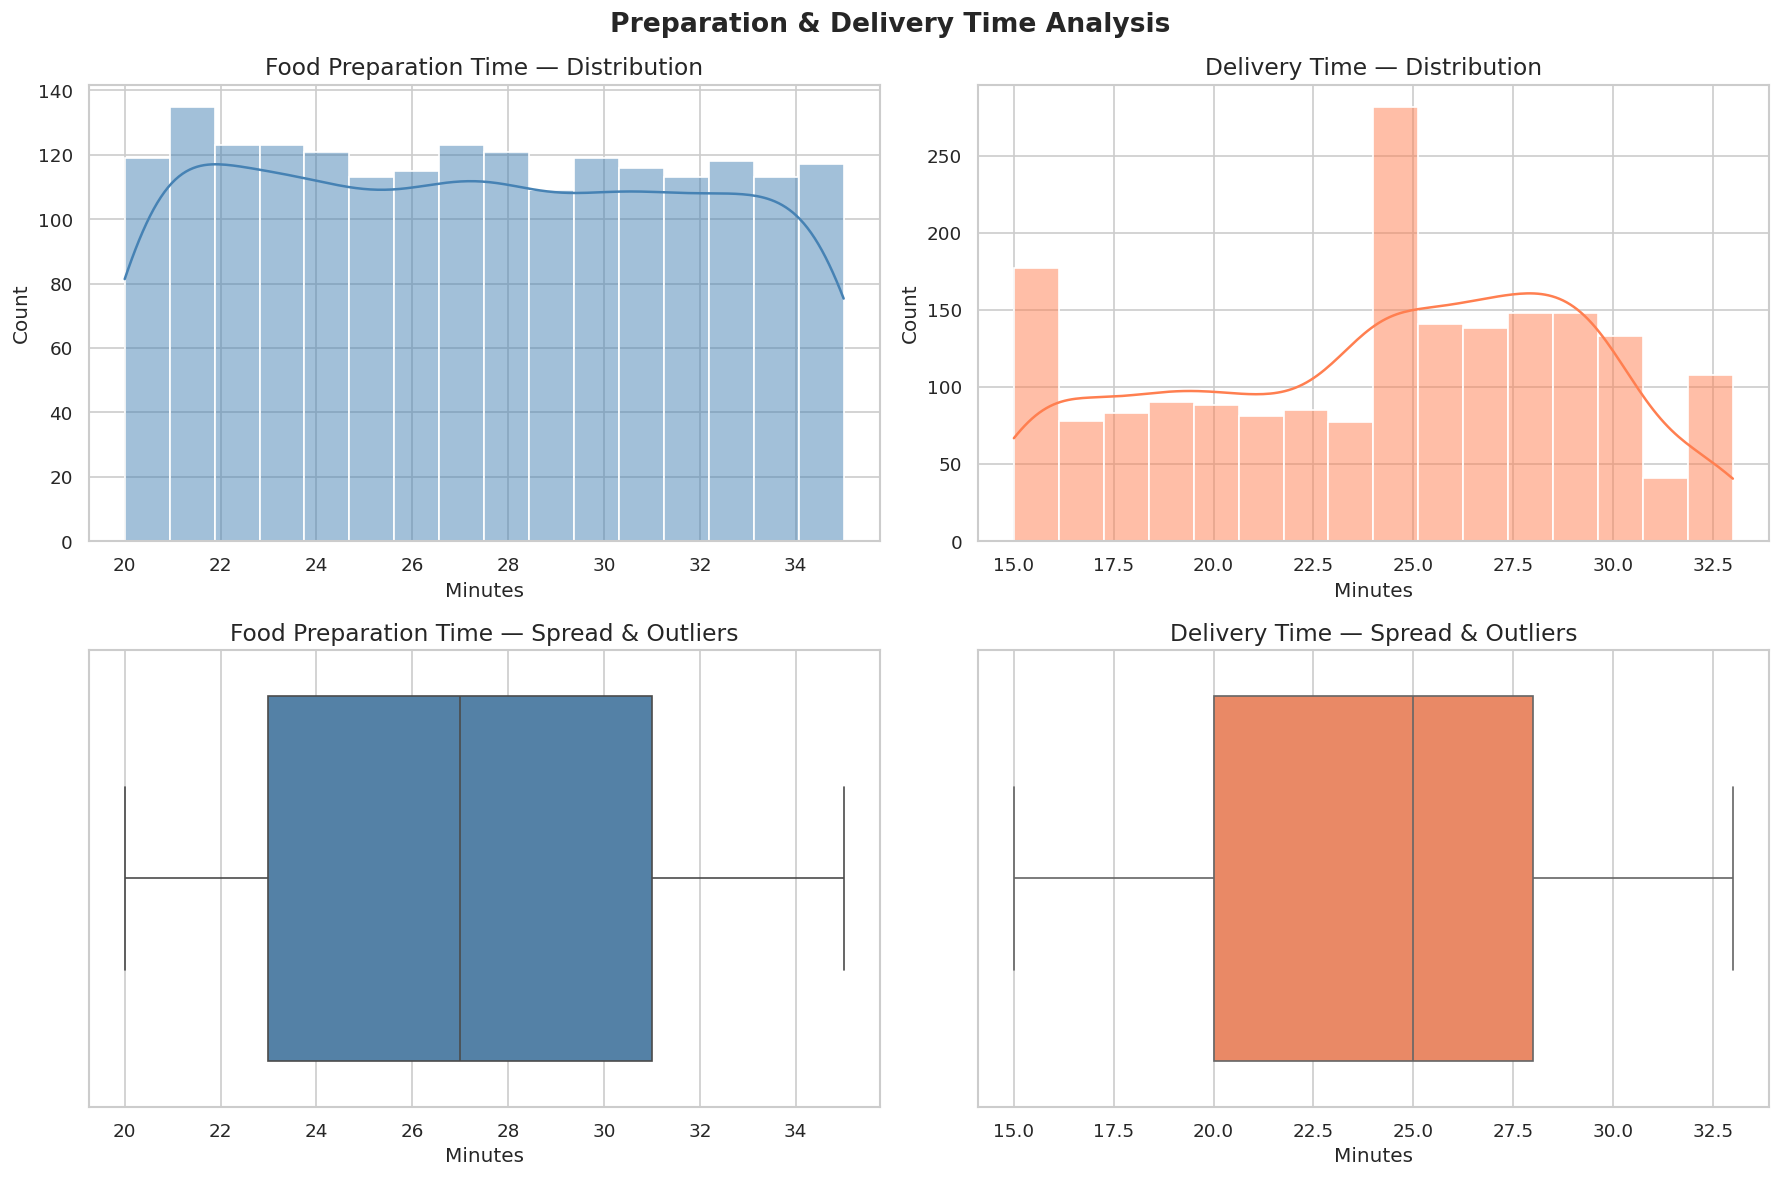

       food_preparation_time  delivery_time
count                1898.00        1898.00
mean                   27.37          24.16
std                     4.63           4.97
min                    20.00          15.00
25%                    23.00          20.00
50%                    27.00          25.00
75%                    31.00          28.00
max                    35.00          33.00


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, col, label, color in zip(
    axes.flat,
    ['food_preparation_time', 'food_preparation_time', 'delivery_time', 'delivery_time'],
    ['Food Preparation Time', 'Food Preparation Time', 'Delivery Time', 'Delivery Time'],
    ['steelblue', 'steelblue', 'coral', 'coral']
):
    pass

# Row 0: histplots
sns.histplot(food['food_preparation_time'], bins=16, kde=True, color='steelblue', ax=axes[0][0])
axes[0][0].set_title('Food Preparation Time — Distribution')
axes[0][0].set_xlabel('Minutes')
axes[0][0].set_ylabel('Count')

sns.histplot(food['delivery_time'], bins=16, kde=True, color='coral', ax=axes[0][1])
axes[0][1].set_title('Delivery Time — Distribution')
axes[0][1].set_xlabel('Minutes')
axes[0][1].set_ylabel('Count')

# Row 1: boxplots
sns.boxplot(x=food['food_preparation_time'], color='steelblue', ax=axes[1][0])
axes[1][0].set_title('Food Preparation Time — Spread & Outliers')
axes[1][0].set_xlabel('Minutes')

sns.boxplot(x=food['delivery_time'], color='coral', ax=axes[1][1])
axes[1][1].set_title('Delivery Time — Spread & Outliers')
axes[1][1].set_xlabel('Minutes')

plt.suptitle('Preparation & Delivery Time Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(food[['food_preparation_time','delivery_time']].describe().round(2))

**Food Preparation Time:**
- Ranges from **20 to 35 minutes** with a mean of ~27.4 minutes.
- The multimodal distribution (peaks at 20, 25, 30, 35) suggests restaurants round preparation times to multiples of 5.
- No outliers — all orders fall within range.

**Delivery Time:**
- Ranges from **15 to 33 minutes** with a mean of ~24.2 minutes.
- Similar multimodal pattern, with the highest frequency at 29 minutes.
- No outliers.

### Orders Exceeding 60 Minutes Total Delivery Time

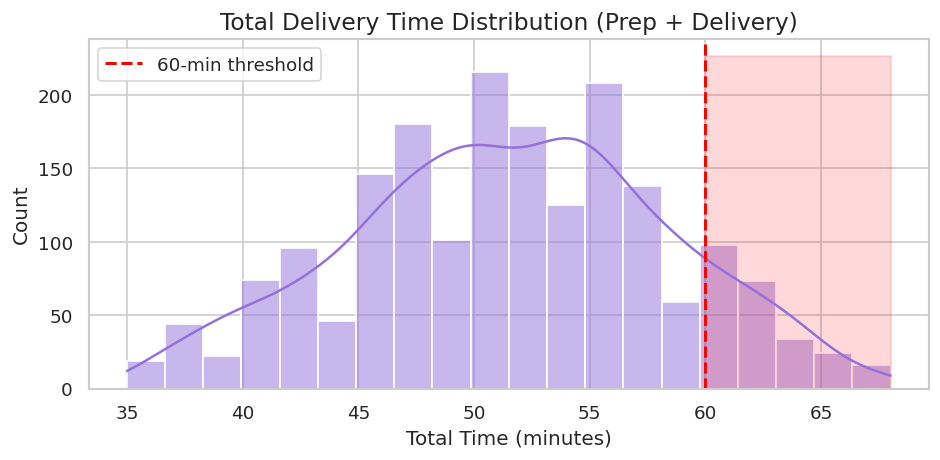

Orders exceeding 60 minutes: 200 (10.54%)
Mean total delivery time   : 51.5 minutes


In [25]:
food['total_time'] = food['food_preparation_time'] + food['delivery_time']

over_60 = food[food['total_time'] > 60]
pct_over_60 = len(over_60) / len(food) * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(food['total_time'], bins=20, kde=True, color='mediumpurple', ax=ax)
ax.axvline(60, color='red', linestyle='--', linewidth=1.8, label='60-min threshold')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 300],
                 60, food['total_time'].max(), alpha=0.15, color='red')
ax.set_title('Total Delivery Time Distribution (Prep + Delivery)')
ax.set_xlabel('Total Time (minutes)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Orders exceeding 60 minutes: {len(over_60):,} ({pct_over_60:.2f}%)")
print(f"Mean total delivery time   : {food['total_time'].mean():.1f} minutes")

**Observations:**
- Approximately **10.54% of orders (200 out of 1,898)** take more than 60 minutes from placement to delivery.
- Roughly **1 in every 10 orders** is at risk of customer dissatisfaction due to long wait times.

### Delivery Time: Weekday vs Weekend

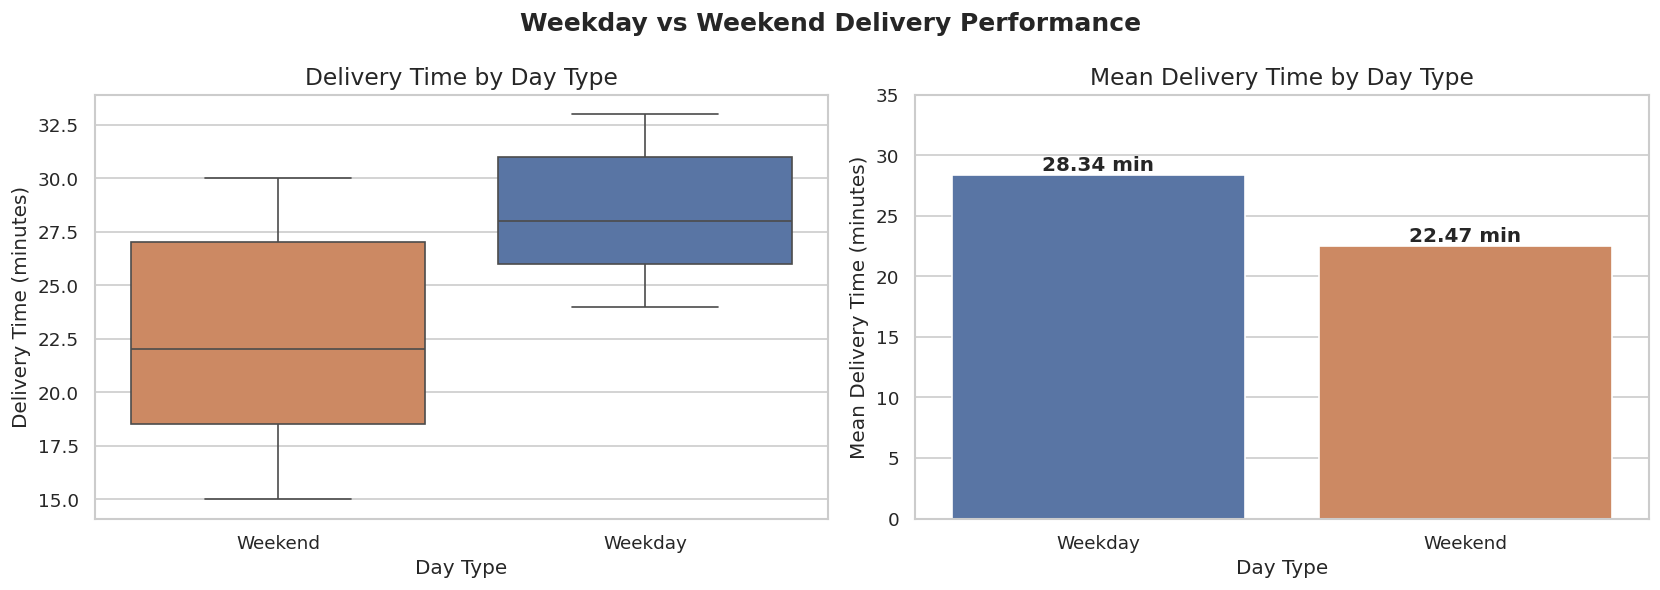

Weekday mean delivery time : 28.34 min
Weekend mean delivery time : 22.47 min
Weekday is slower by       : 5.87 minutes (26.1% longer)


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot comparison
sns.boxplot(data=food, x='day_of_the_week', y='delivery_time',
            palette={'Weekday': '#4C72B0', 'Weekend': '#DD8452'}, ax=axes[0])
axes[0].set_title('Delivery Time by Day Type')
axes[0].set_xlabel('Day Type')
axes[0].set_ylabel('Delivery Time (minutes)')

# Mean comparison bar
mean_delivery = food.groupby('day_of_the_week')['delivery_time'].mean().round(2)
bars = sns.barplot(x=mean_delivery.index, y=mean_delivery.values,
                   palette={'Weekday': '#4C72B0', 'Weekend': '#DD8452'}, ax=axes[1])
axes[1].set_title('Mean Delivery Time by Day Type')
axes[1].set_xlabel('Day Type')
axes[1].set_ylabel('Mean Delivery Time (minutes)')
axes[1].set_ylim(0, 35)
for bar, val in zip(axes[1].patches, mean_delivery.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{val} min', ha='center', fontweight='bold')

plt.suptitle('Weekday vs Weekend Delivery Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

diff = mean_delivery['Weekday'] - mean_delivery['Weekend']
print(f"Weekday mean delivery time : {mean_delivery['Weekday']} min")
print(f"Weekend mean delivery time : {mean_delivery['Weekend']} min")
print(f"Weekday is slower by       : {diff:.2f} minutes ({diff/mean_delivery['Weekend']*100:.1f}% longer)")

**Observations:**
- **Weekday deliveries (28.34 min)** are significantly slower than **weekend deliveries (22.47 min)** — a difference of nearly 6 minutes.
- This is counterintuitive: weekdays have far fewer orders (547 vs 1,351), yet deliveries take longer.
- Possible explanations: fewer active delivery agents on weekdays, or different restaurant/traffic patterns.

### Food Preparation Time by Cuisine

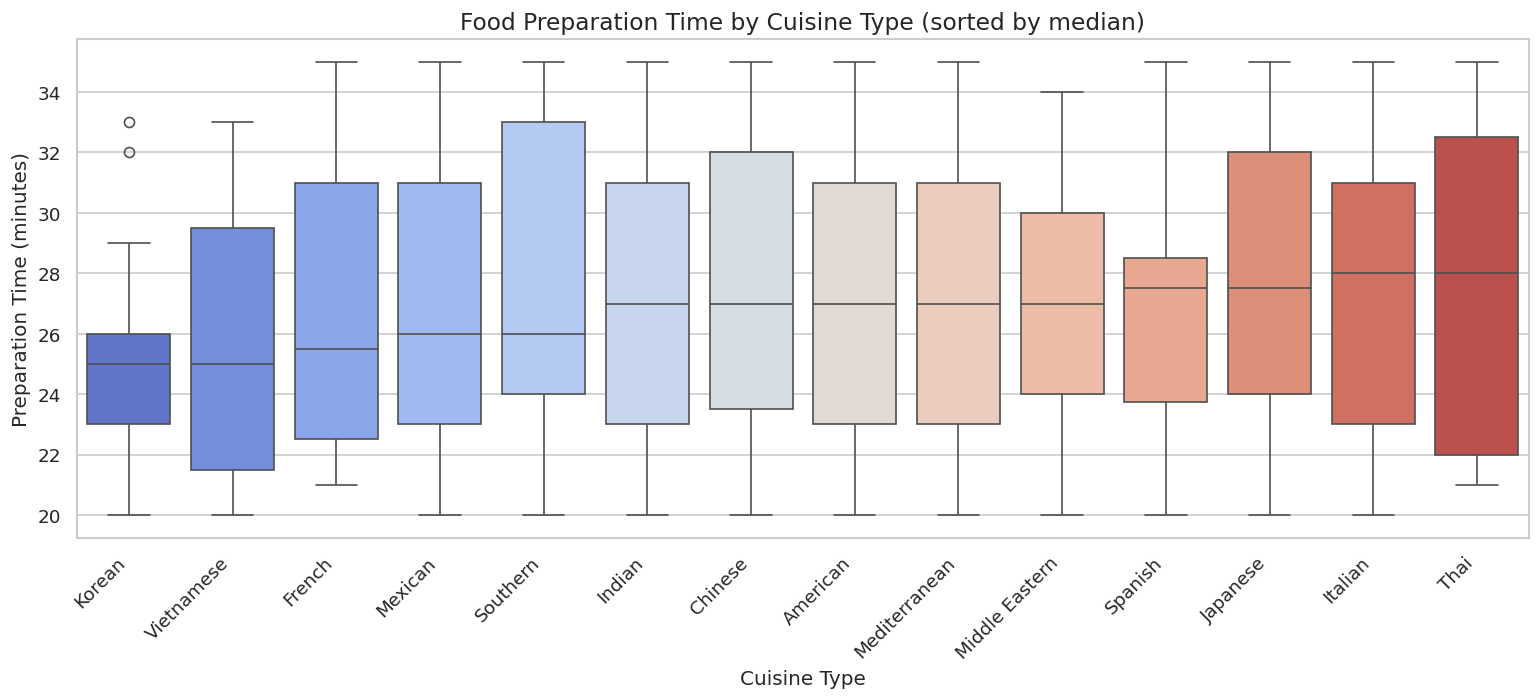

In [27]:
fig, ax = plt.subplots(figsize=(13, 6))

cuisine_order = food.groupby('cuisine_type')['food_preparation_time'].median().sort_values().index
sns.boxplot(data=food, x='cuisine_type', y='food_preparation_time',
            order=cuisine_order, palette='coolwarm', ax=ax)
ax.set_title('Food Preparation Time by Cuisine Type (sorted by median)')
ax.set_xlabel('Cuisine Type')
ax.set_ylabel('Preparation Time (minutes)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observations:**
- **Korean** cuisine has the lowest median prep time (~25 min) — the fastest to prepare.
- **Thai** and **Southern** cuisines have the highest medians (~28–33 min) and the most variability.
- Most mainstream cuisines (American, Italian, Mexican, Chinese) cluster around **27 minutes**.
- **Middle Eastern** has a notably wide spread (20–34 min), indicating inconsistent preparation times.

---
## 5. Revenue Analysis

This section examines order cost patterns and calculates FoodHub's net revenue.

### Order Cost Distribution

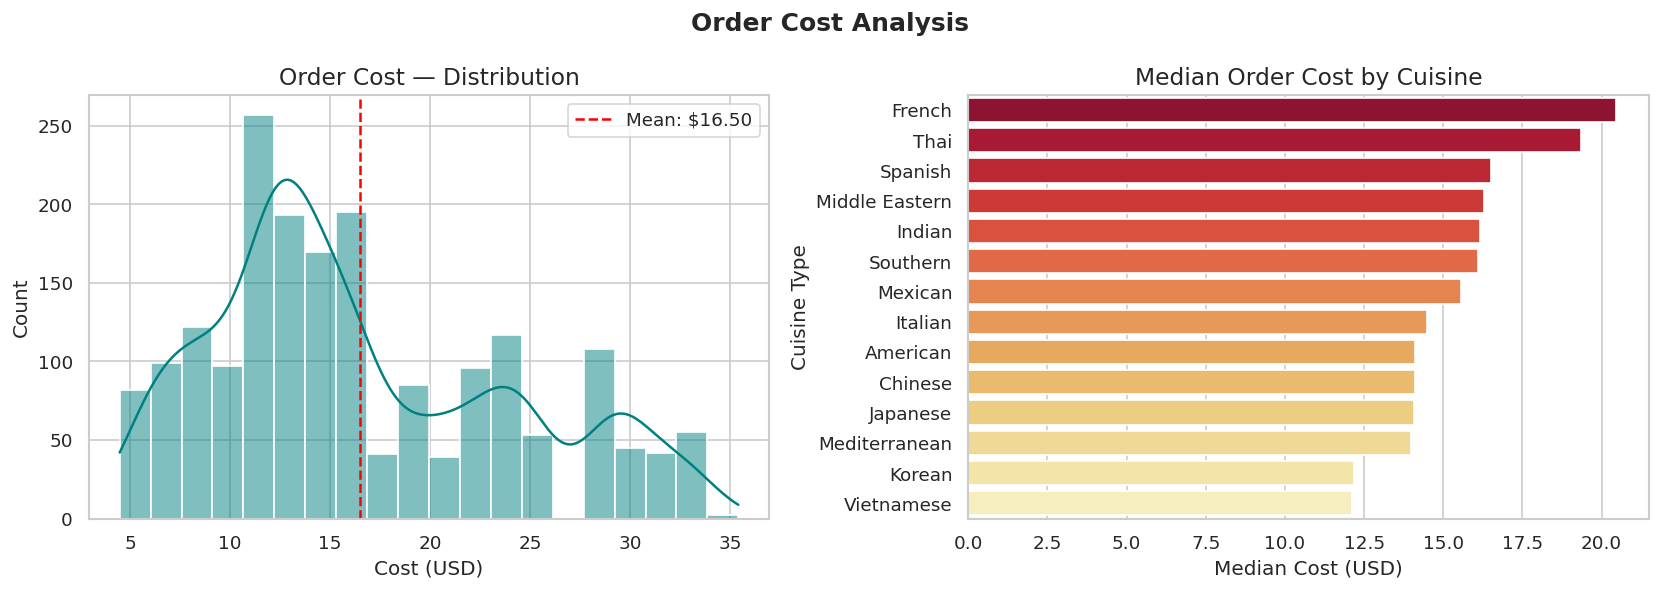

Orders above $20 : 555 (29.24%)
Mean order cost  : $16.50


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(food['cost_of_the_order'], bins=20, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Order Cost — Distribution')
axes[0].set_xlabel('Cost (USD)')
axes[0].set_ylabel('Count')
axes[0].axvline(food['cost_of_the_order'].mean(), color='red', linestyle='--',
                label=f"Mean: ${food['cost_of_the_order'].mean():.2f}")
axes[0].legend()

# Cost by cuisine (median)
cuisine_cost = food.groupby('cuisine_type')['cost_of_the_order'].median().sort_values(ascending=False)
sns.barplot(x=cuisine_cost.values, y=cuisine_cost.index, palette='YlOrRd_r', ax=axes[1])
axes[1].set_title('Median Order Cost by Cuisine')
axes[1].set_xlabel('Median Cost (USD)')
axes[1].set_ylabel('Cuisine Type')

plt.suptitle('Order Cost Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

orders_above_20 = food[food['cost_of_the_order'] > 20]
pct_above_20 = len(orders_above_20) / len(food) * 100
print(f"Orders above $20 : {len(orders_above_20):,} ({pct_above_20:.2f}%)")
print(f"Mean order cost  : ${food['cost_of_the_order'].mean():.2f}")

**Observations:**
- The distribution is **right-skewed** — most orders cluster between $10–$15, with fewer high-value orders.
- **29.24% of orders** cost more than $20.
- **French** cuisine has the highest median cost (~$20), while **Korean** is the most affordable (~$13).
- Day of the week has virtually no impact on order cost — customers spend similarly on weekdays and weekends.

### Net Revenue Calculation

In [29]:
# Commission tiers:
# 25% on orders > $20
# 15% on orders between $5 and $20

orders_above_20 = food[food['cost_of_the_order'] > 20].copy()
orders_5_to_20  = food[(food['cost_of_the_order'] > 5) & (food['cost_of_the_order'] <= 20)].copy()

orders_above_20['commission'] = orders_above_20['cost_of_the_order'] * 0.25
orders_5_to_20['commission']  = orders_5_to_20['cost_of_the_order']  * 0.15

rev_high = orders_above_20['commission'].sum()
rev_mid  = orders_5_to_20['commission'].sum()
net_revenue = rev_high + rev_mid

print("=" * 38)
print("       FoodHub Revenue Summary")
print("=" * 38)
print(f"Orders above $20    : {len(orders_above_20):>5,}  →  ${rev_high:>8,.2f}  (25% tier)")
print(f"Orders $5–$20       : {len(orders_5_to_20):>5,}  →  ${rev_mid:>8,.2f}  (15% tier)")
print("-" * 38)
print(f"Net Revenue         :         ${net_revenue:>8,.2f}")
print("=" * 38)

       FoodHub Revenue Summary
Orders above $20    :   555  →  $3,688.73  (25% tier)
Orders $5–$20       : 1,334  →  $2,477.58  (15% tier)
--------------------------------------
Net Revenue         :         $6,166.30


**Observations:**
- FoodHub's **net revenue across all orders is $6,166.30**.
- Higher-margin orders (>$20 at 25% commission) contribute significantly despite being only ~29% of orders.
- Encouraging more high-value orders would directly boost revenue.

---
## 6. Rating Analysis

This section explores what drives customer ratings and identifies which restaurants qualify for promotional offers.

### Correlation Between Numerical Variables

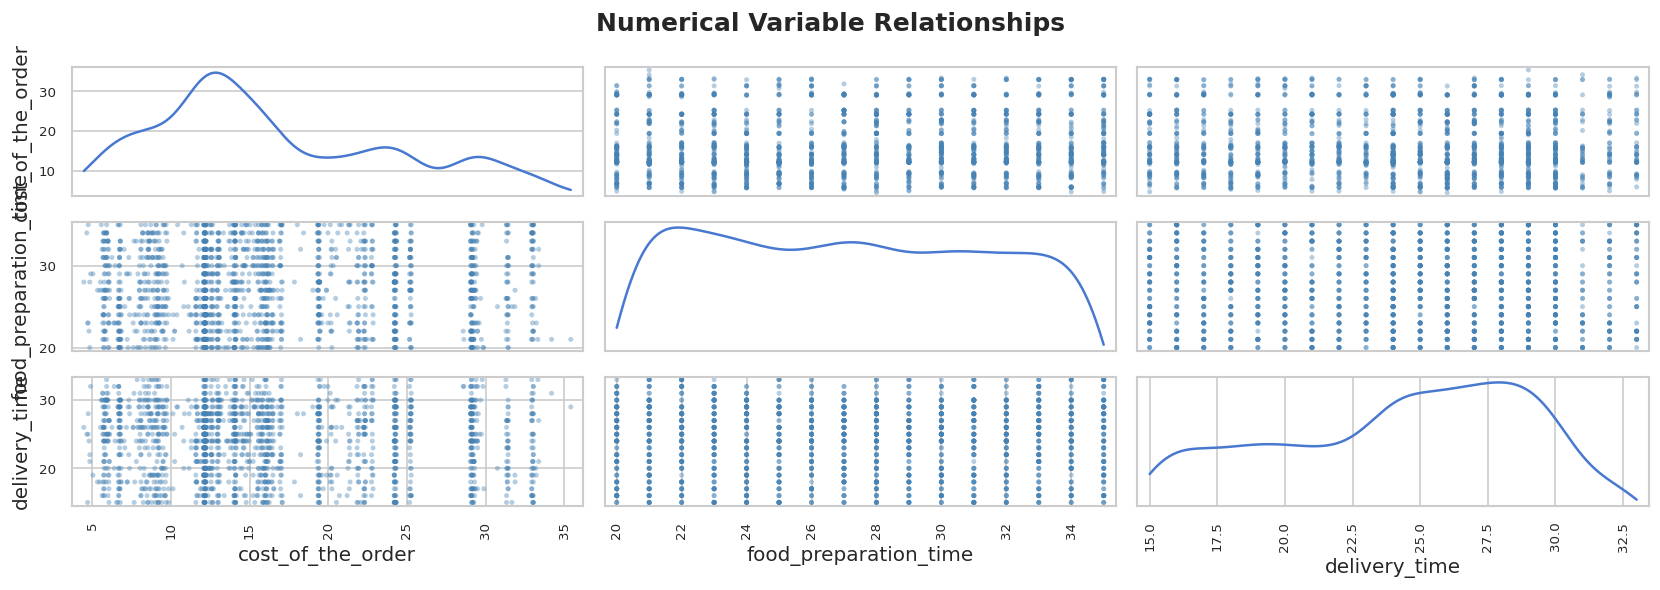

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
corr = food[['cost_of_the_order', 'food_preparation_time', 'delivery_time']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[0], linewidths=0.5)
axes[0].set_title('Correlation Matrix')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Pairplot approximation (scatter matrix) using pandas
pd.plotting.scatter_matrix(
    food[['cost_of_the_order', 'food_preparation_time', 'delivery_time']],
    ax=axes[1], figsize=(6, 6), diagonal='kde', alpha=0.4, color='steelblue'
)
axes[1].set_title('Pairwise Scatter Matrix')

plt.suptitle('Numerical Variable Relationships', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- All three numerical variables — cost, preparation time, and delivery time — have **correlations near zero** with each other.
- This means **none of the numerical variables are linearly related** to one another.
- Combined with the finding below, this suggests customer satisfaction is driven by factors not captured in this dataset (food quality, packaging, order accuracy).

### Do Cost, Preparation Time, or Delivery Time Affect Ratings?

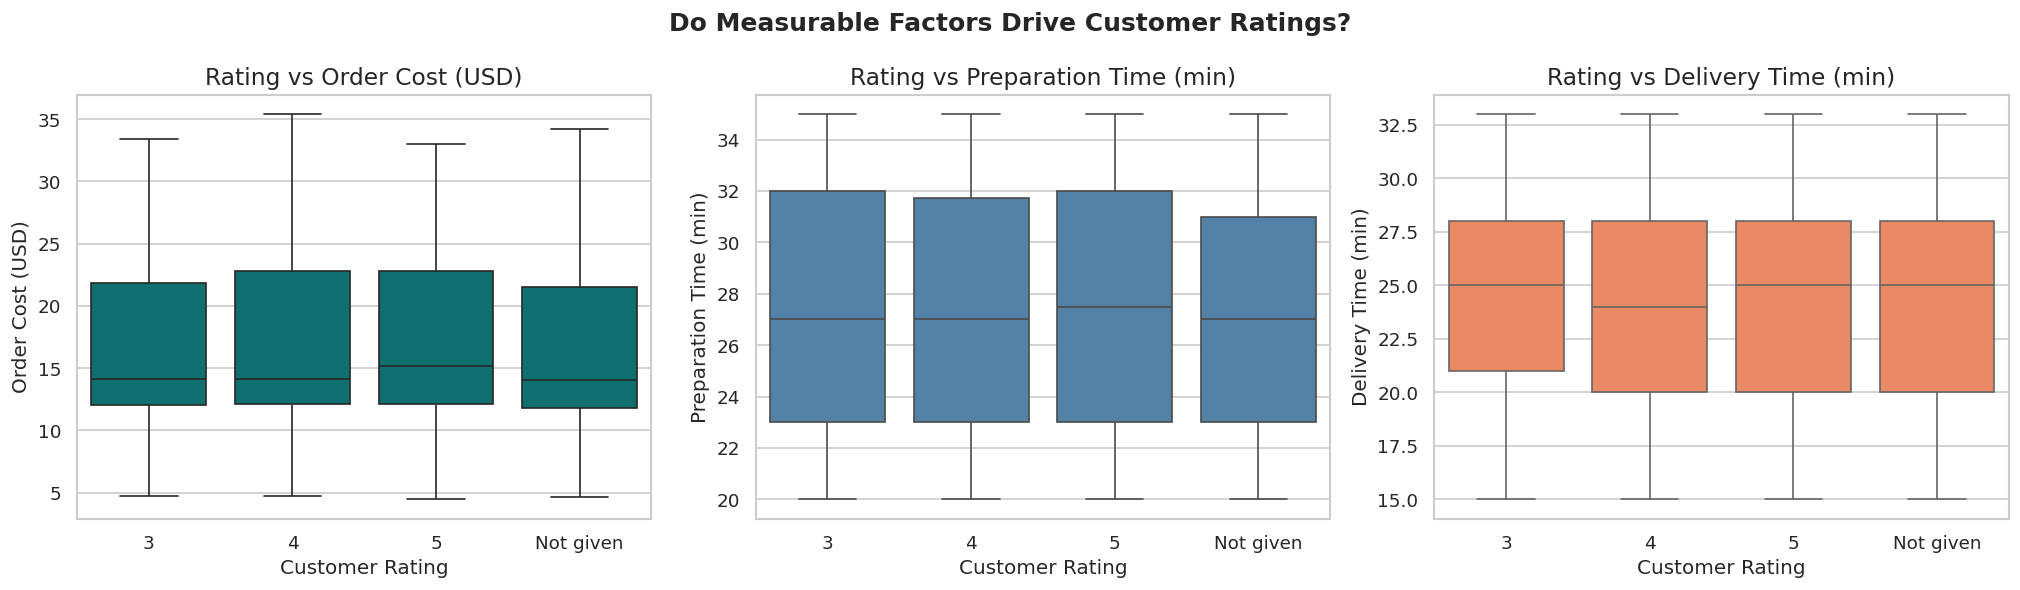

In [31]:
rated = food[food['rating'] != 'Not given'].copy()
rated['rating'] = pd.to_numeric(rated['rating'])
rating_order = ['3', '4', '5', 'Not given']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, label, color in zip(
    axes,
    ['cost_of_the_order', 'food_preparation_time', 'delivery_time'],
    ['Order Cost (USD)', 'Preparation Time (min)', 'Delivery Time (min)'],
    ['teal', 'steelblue', 'coral']
):
    sns.boxplot(data=food, x='rating', y=col,
                order=['3', '4', '5', 'Not given'], color=color, ax=ax)
    ax.set_title(f'Rating vs {label}')
    ax.set_xlabel('Customer Rating')
    ax.set_ylabel(label)

plt.suptitle('Do Measurable Factors Drive Customer Ratings?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations — a surprising finding:**
- **Order cost** has virtually no impact on ratings. Customers who gave 3, 4, or 5 all spent similar amounts.
- **Food preparation time** is nearly identical across all rating groups (median ~27 min for all).
- **Delivery time** also shows no meaningful difference between rating groups.
- **None of the three numerical variables in this dataset significantly drive customer ratings.**
- This strongly suggests ratings are influenced by **factors not captured here** — food quality, packaging, app experience, or order accuracy.

### Restaurants Qualifying for Promotional Offers

*Criteria: rating count > 50 AND average rating > 4.0*

4 restaurants qualify for the promotional offer:

          restaurant_name  rating_count  avg_rating
        The Meatball Shop            84       4.512
Blue Ribbon Fried Chicken            64       4.328
              Shake Shack           133       4.278
        Blue Ribbon Sushi            73       4.219




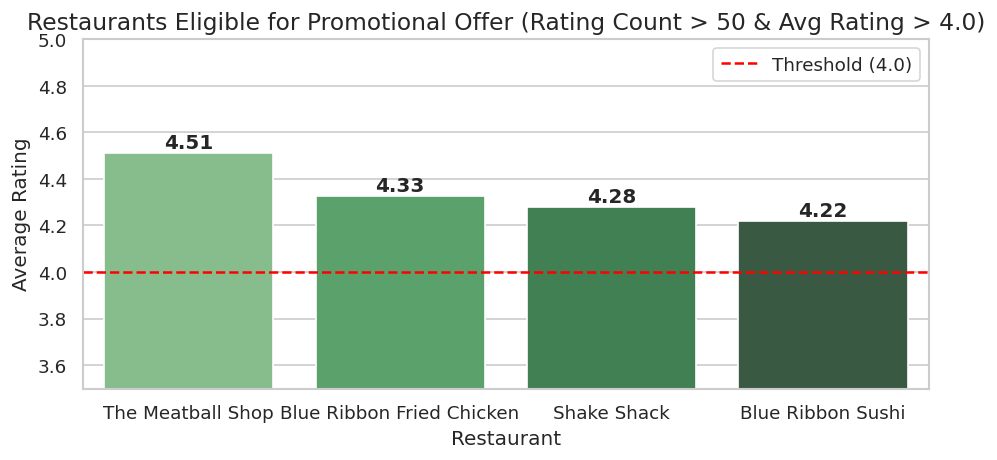

In [34]:
rated = food[food['rating'] != 'Not given'].copy()
rated['rating'] = pd.to_numeric(rated['rating'])

rating_count = rated.groupby('restaurant_name')['rating'].count().reset_index()
rating_count.columns = ['restaurant_name', 'rating_count']

avg_rating = rated.groupby('restaurant_name')['rating'].mean().reset_index()
avg_rating.columns = ['restaurant_name', 'avg_rating']

eligible = (
    rating_count.merge(avg_rating, on='restaurant_name')
    .query('rating_count > 50 and avg_rating > 4.0')
    .sort_values('avg_rating', ascending=False)
    .reset_index(drop=True)
)
eligible['avg_rating'] = eligible['avg_rating'].round(3)
print(f"{len(eligible)} restaurants qualify for the promotional offer:\n")
print(eligible.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = sns.barplot(data=eligible, x='restaurant_name', y='avg_rating',
                   palette='Greens_d', ax=ax)
print('\n')
ax.set_title('Restaurants Eligible for Promotional Offer (Rating Count > 50 & Avg Rating > 4.0)')
ax.set_xlabel('Restaurant')
ax.set_ylabel('Average Rating')
ax.set_ylim(3.5, 5.0)
ax.axhline(4.0, color='red', linestyle='--', label='Threshold (4.0)')
ax.legend()
for bar, val in zip(ax.patches, eligible['avg_rating']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- Only **4 restaurants** qualify: **Shake Shack, The Meatball Shop, Blue Ribbon Sushi,** and **Blue Ribbon Fried Chicken**.
- Notably, these are the same restaurants that make up the **top 4 by order volume** — combining popularity with quality.
- These are FoodHub's most valuable restaurant partners and deserve priority placement and promotion.

---
## 7. Conclusions & Recommendations

### Key Findings Summary

| # | Finding | Metric |
|---|---|---|
| 1 | Shake Shack is the most ordered restaurant | 219 orders (11.54% of total) |
| 2 | American cuisine dominates the platform | ~585 orders |
| 3 | Platform is heavily weekend-driven | Weekends: 2.5× more orders than weekdays |
| 4 | Weekday deliveries are significantly slower | 28.34 min vs 22.47 min on weekends |
| 5 | 10.54% of orders exceed 60 minutes total | ~1 in 10 orders risks dissatisfaction |
| 6 | 38.8% of orders are unrated | 736 out of 1,898 orders |
| 7 | Net revenue across all orders | $6,166.30 |
| 8 | Only 4 restaurants qualify for the promo | Rating count >50 AND avg rating >4.0 |

### Recommendations

**1. Expand capacity for high-demand cuisines**
American and Japanese cuisines drive the majority of orders. FoodHub should onboard more restaurants in these categories to prevent over-reliance on a single restaurant (Shake Shack has 11.5% of all orders alone) and reduce delivery delays caused by bottlenecks.

**2. Fix weekday delivery performance**
Weekday delivery takes 26% longer than weekends despite having 2.5× fewer orders. FoodHub should investigate whether this stems from fewer delivery agents, traffic patterns, or restaurant staffing — and deploy resources accordingly during weekday peak hours.

**3. Reduce the 60-minute tail**
~10.5% of orders take over an hour. FoodHub should identify which restaurants and cuisine types (especially Thai and Southern) are driving these delays and implement preparation-time SLAs or real-time alerts.

**4. Close the rating gap**
38.8% of orders are unrated, which is a major feedback blind spot. Introduce lightweight in-app prompts or small incentives (loyalty points, discount coupons) immediately after delivery to improve the response rate.

**5. Promote the four qualifying restaurants**
Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken combine high volume *and* high ratings — the ideal combination. Feature them prominently in the app to drive more orders and revenue.

**6. Drive weekday order volume**
Weekday capacity is underutilized. Targeted weekday promotions (flash discounts, free delivery on weekday orders) could attract more customers while better distributing load across the week.

**7. Increase high-value order share**
Orders above $20 generate a 25% commission vs 15% for smaller orders. Bundle deals, family meal promotions, and "free delivery above $25" incentives would shift order mix toward the higher-margin tier and grow net revenue.